# Hedging Strategy Fundamentals

This notebook introduces the core ideas behind hedging across asset classes, with emphasis on hedge ratio selection, perfect hedges, and practical trade-offs.

## Learning Objectives

After working through this notebook, you should be able to:

- explain why hedging is used in risk management
- distinguish between a perfect hedge and an imperfect hedge
- compute a hedge ratio in simple and minimum-variance settings
- recognize how hedging differs across equities, FX, interest rates, and commodities

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. What Is a Hedge?

A hedge is a position taken to reduce the risk of an existing exposure. The goal is usually not to maximize upside, but to reduce sensitivity to a risk factor such as price, foreign exchange, interest rate, or volatility risk.

Examples:

- an airline hedging jet fuel costs with oil or fuel derivatives
- a European investor hedging USD exposure with FX forwards
- a bond portfolio manager hedging duration with interest rate futures
- a farmer hedging crop prices with commodity futures

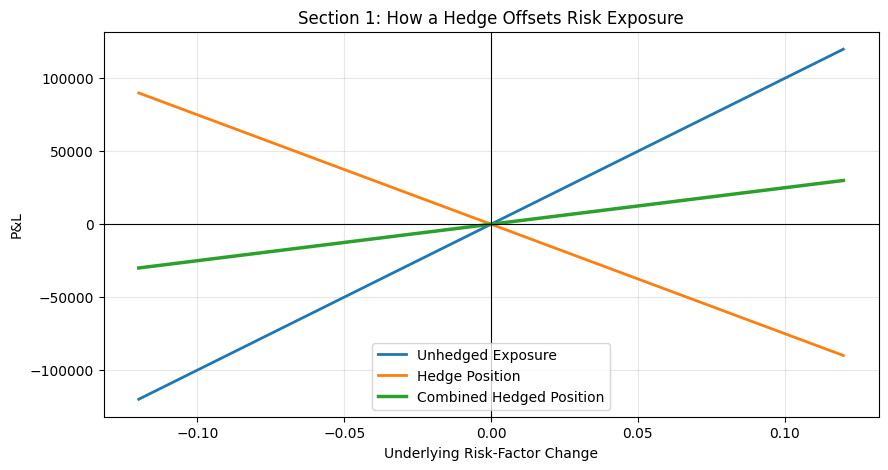

In [22]:
risk_factor = np.linspace(-0.12, 0.12, 200)
exposure_pnl = 1_000_000 * risk_factor
hedge_offset = -0.75 * exposure_pnl
combined_pnl = exposure_pnl + hedge_offset


plt.figure(figsize=(10, 5))
plt.plot(risk_factor, exposure_pnl, label='Unhedged Exposure', linewidth=2)
plt.plot(risk_factor, hedge_offset, label='Hedge Position', linewidth=2)
plt.plot(risk_factor, combined_pnl, label='Combined Hedged Position', linewidth=2.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Section 1: How a Hedge Offsets Risk Exposure')
plt.xlabel('Underlying Risk-Factor Change')
plt.ylabel('P&L')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**How to read this graph**

- **Unhedged Exposure** (blue) shows the portfolio P&L sensitivity to the underlying risk-factor move.
- **Hedge Position** (orange) moves in the opposite direction and offsets part of that sensitivity.
- **Combined Hedged Position** (green) is the net result after adding exposure and hedge P&L.


**Interpretation:** the flatter the combined line around zero, the more effective the hedge. In this example, the hedge reduces slope materially, so downside and upside swings are both dampened relative to the unhedged exposure.

## 2. Hedge Ratio

The hedge ratio tells us how large the hedge position should be relative to the original exposure.

A simple definition is:

$h = \frac{\text{value of hedge position}}{\text{value of exposure}}$

In futures hedging, a practical contract-based version is often written as:

$N = h \times \frac{Q_A}{Q_F}$

where:

- $N$ is the number of futures contracts
- $h$ is the hedge ratio
- $Q_A$ is the size of the asset exposure
- $Q_F$ is the size of one futures contract

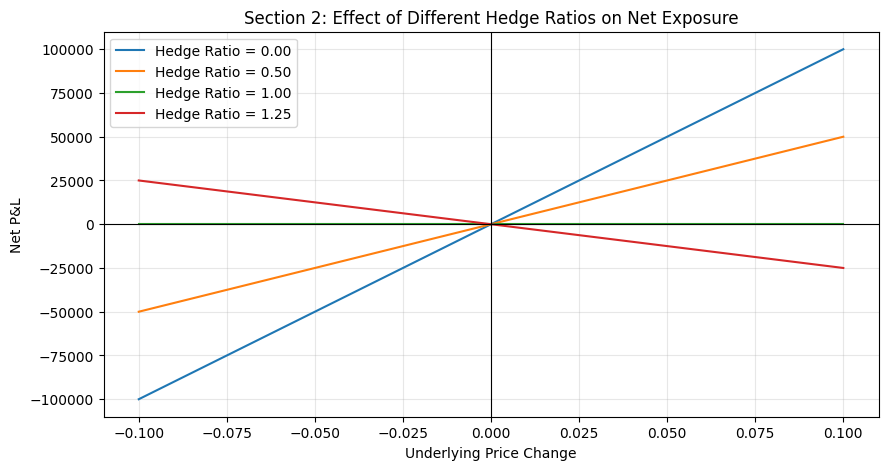

In [23]:
price_move = np.linspace(-0.10, 0.10, 200)
hedge_ratios = [0.0, 0.5, 1.0, 1.25]


plt.figure(figsize=(10, 5))
for ratio in hedge_ratios:
    net_pnl = 1_000_000 * (price_move - ratio * price_move)
    plt.plot(price_move, net_pnl, label=f'Hedge Ratio = {ratio:.2f}')


plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Section 2: Effect of Different Hedge Ratios on Net Exposure')
plt.xlabel('Underlying Price Change')
plt.ylabel('Net P&L')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Perfect Hedge

A perfect hedge removes all uncertainty in the value of the combined position. This happens when gains and losses on the hedge exactly offset losses and gains on the exposure.

This is most realistic when:

- the hedging instrument references the same underlying risk factor
- the hedge amount matches the exposure exactly
- the hedge horizon matches the exposure horizon
- there is no basis risk, liquidity issue, or timing mismatch
- transaction costs and margin effects are ignored

In practice, most hedges are imperfect because the hedge instrument is only correlated with the underlying exposure rather than identical to it.

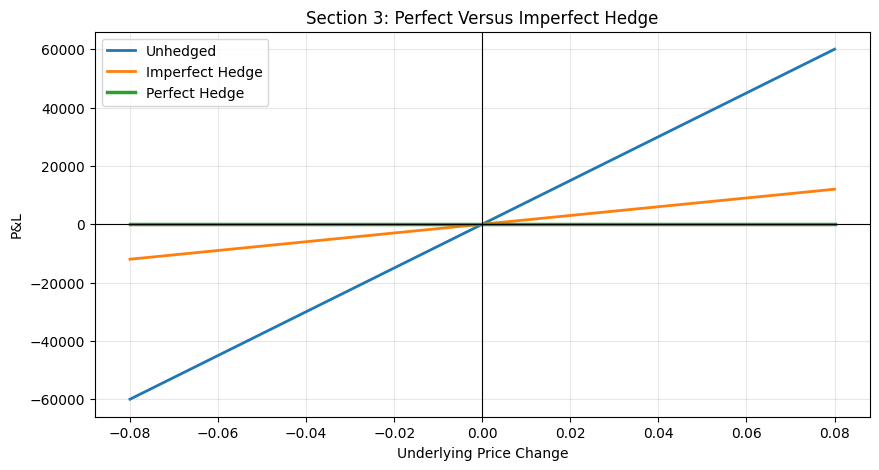

In [24]:
spot_move = np.linspace(-0.08, 0.08, 200)
perfect_hedge_pnl = 750_000 * (spot_move - spot_move)
imperfect_hedge_pnl = 750_000 * (spot_move - 0.8 * spot_move)
unhedged_pnl_demo = 750_000 * spot_move


plt.figure(figsize=(10, 5))
plt.plot(spot_move, unhedged_pnl_demo, label='Unhedged', linewidth=2)
plt.plot(spot_move, imperfect_hedge_pnl, label='Imperfect Hedge', linewidth=2)
plt.plot(spot_move, perfect_hedge_pnl, label='Perfect Hedge', linewidth=2.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Section 3: Perfect Versus Imperfect Hedge')
plt.xlabel('Underlying Price Change')
plt.ylabel('P&L')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Minimum-Variance Hedge Ratio

When the hedge is not perfect, a common objective is to choose the hedge ratio that minimizes the variance of the hedged position. The classical minimum-variance hedge ratio is:

$h^* = \rho \frac{\sigma_S}{\sigma_F}$

where:

- $\rho$ is the correlation between spot and futures changes
- $\sigma_S$ is the volatility of spot price changes
- $\sigma_F$ is the volatility of futures price changes

The closer correlation is to 1, the more effective the hedge tends to be.

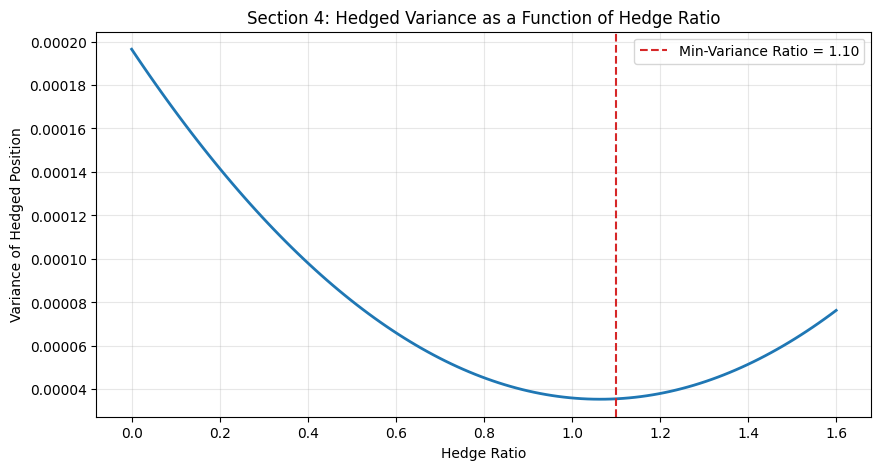

In [50]:
candidate_ratios = np.linspace(0.0, 1.6, 120)
hedged_variance = []
for ratio in candidate_ratios:
    hedged_series = sim_data['spot_return'] - ratio * sim_data['futures_return'] if 'sim_data' in globals() else None
    if hedged_series is None:
        rho_demo = 0.88
        sigma_spot_demo = 0.015
        sigma_futures_demo = 0.012
        variance_value = sigma_spot_demo ** 2 + ratio ** 2 * sigma_futures_demo ** 2 - 2 * ratio * rho_demo * sigma_spot_demo * sigma_futures_demo
    else:
        variance_value = hedged_series.var()
    hedged_variance.append(variance_value)


plt.figure(figsize=(10, 5))
plt.plot(candidate_ratios, hedged_variance, linewidth=2)
plt.axvline(h_star, color='tab:red', linestyle='--', label=f'Min-Variance Ratio = {h_star:.2f}')
plt.title('Section 4: Hedged Variance as a Function of Hedge Ratio')
plt.xlabel('Hedge Ratio')
plt.ylabel('Variance of Hedged Position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
def minimum_variance_hedge_ratio(rho, sigma_spot, sigma_futures):
    return rho * sigma_spot / sigma_futures

rho = 0.88
sigma_spot = 0.015
sigma_futures = 0.012

h_star = minimum_variance_hedge_ratio(rho, sigma_spot, sigma_futures)
h_star

1.0999999999999999

## 5. Hedging Examples by Asset Class

### Equities

A portfolio manager holding a broad equity portfolio may hedge market risk using index futures. If the concern is systematic market exposure, the hedge can be adjusted using portfolio beta:

$N = \frac{\beta_P V_P}{V_F}$

where $\beta_P$ is the portfolio beta, $V_P$ is the portfolio value, and $V_F$ is the notional value per futures contract.

This is not usually a perfect hedge because idiosyncratic stock risk remains.

### Foreign Exchange

Suppose a USD-based investor expects to receive EUR 10 million in three months. Selling EUR forward can hedge the FX risk. If the forward notional and maturity match the future receipt, the hedge can be close to perfect.

Key residual risks include credit risk, timing mismatches, and cash-flow uncertainty if the final receipt is not known exactly.

### Interest Rates


Fixed income hedging often relies on duration or DV01 matching. A bond portfolio can be hedged with Treasury futures or swaps so that the portfolio's sensitivity to small rate changes is reduced.


Duration measures how sensitive a bond price is to a change in yield. In practice, modified duration is the most common version used for hedging, because it approximates the percentage change in price for a small change in yield:


$\frac{\Delta P}{P} \approx -D_{mod} \times \Delta y$


If a bond has modified duration of 6, then a 1% increase in yield implies roughly a 6% decline in price, ignoring convexity. Duration is useful because it normalizes rate sensitivity across bonds of different sizes, coupons, and maturities.


DV01, or dollar value of 1 basis point, translates that same sensitivity into dollars. It tells you how much the bond or portfolio value changes if yield moves by 1 basis point, where 1 basis point is $0.01\%$. A convenient approximation is:


$DV01 \approx D_{mod} \times P \times 0.0001$


This makes DV01 especially important for hedging real portfolios, because traders and risk managers usually need to neutralize dollar risk, not just percentage risk. Two portfolios can have the same duration but very different market values, so their actual P&L exposure to rates can be very different. DV01 captures that immediately.


Why these metrics matter:


- Duration is useful for comparing the relative interest-rate sensitivity of different bonds or portfolios.
- DV01 is useful for sizing a hedge, because it expresses the hedge target in actual dollars per basis point.
- Duration-based hedging is intuitive and fast, but DV01-based hedging is usually more practical for trading and daily risk management.
- When rates move only a little, duration and DV01 work well; when moves are larger, convexity becomes more important and the hedge becomes less exact.


A simplified duration-based hedge ratio is:


$h = \frac{D_P V_P}{D_H V_H}$


where $D_P$ and $D_H$ are durations of the portfolio and hedge instrument. A closely related DV01-based view is to choose the hedge so that portfolio DV01 and hedge DV01 offset each other as much as possible.


This hedge is imperfect if yield curve shifts are not parallel or if the instruments have different convexity.

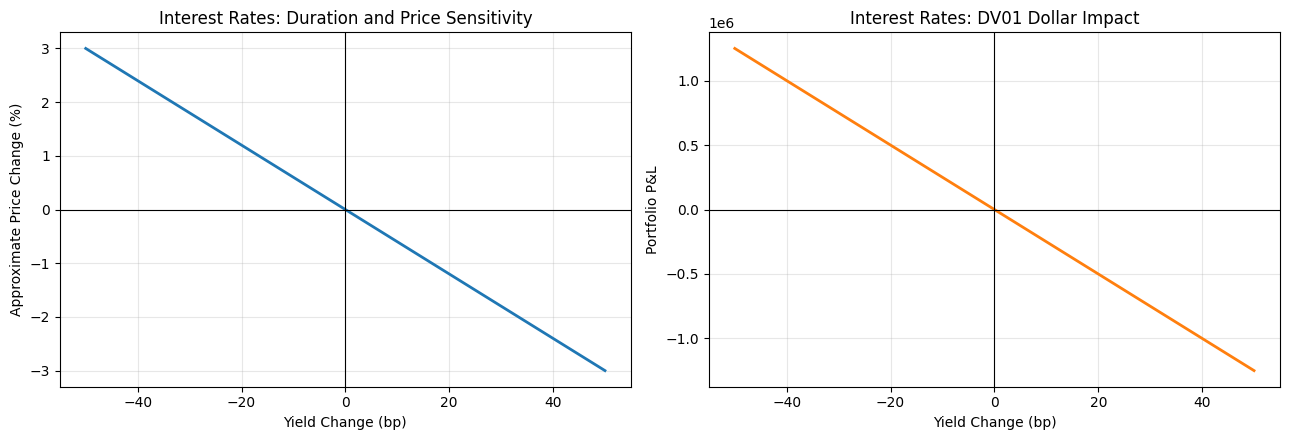

In [27]:
yield_shock_bp = np.linspace(-50, 50, 200)
bond_price_change_pct = -6.0 * (yield_shock_bp / 10000)
dv01_pnl = -25_000 * (yield_shock_bp)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(yield_shock_bp, bond_price_change_pct * 100, linewidth=2)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Interest Rates: Duration and Price Sensitivity')
axes[0].set_xlabel('Yield Change (bp)')
axes[0].set_ylabel('Approximate Price Change (%)')
axes[0].grid(True, alpha=0.3)


axes[1].plot(yield_shock_bp, dv01_pnl, color='tab:orange', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Interest Rates: DV01 Dollar Impact')
axes[1].set_xlabel('Yield Change (bp)')
axes[1].set_ylabel('Portfolio P&L')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

#### How Treasury Futures and Swaps Work




Treasury futures are exchange-traded contracts whose value is linked to a deliverable basket of government bonds. A trader does not usually buy one single bond through the contract. Instead, at delivery the short side has the right to choose one bond from the eligible basket, subject to the exchange rules for maturity and coupon range. Because the basket contains several possible bonds, the contract does not map perfectly to any one cash bond. That is why hedgers pay close attention to the cheapest-to-deliver, or CTD, bond.


The delivery economics are adjusted through the conversion factor system. Each eligible bond has a conversion factor intended to normalize bonds with different coupons and maturities to a common contract standard. The invoice price that the long pays at delivery is approximately:




$\text{Invoice Price} = \text{Futures Settlement Price} \times CF + \text{Accrued Interest}$




In practice, the short compares all deliverable bonds and chooses the one that is cheapest to source and deliver after accounting for the conversion factor. That bond becomes the main driver of the futures contract's rate sensitivity. For a hedger, this matters because the DV01 and duration of the hedge are really tied to the CTD bond, not to a generic notional Treasury.


Delivery and daily mechanics for Treasury futures are straightforward:




- the position is marked to market each day, so gains and losses are settled through variation margin
- the contract has a fixed expiry month and a delivery window defined by exchange rules
- the short may hold into delivery, but many hedgers close or roll the position before that stage
- hedge performance depends on yield moves, basis changes, financing conditions, and changes in the CTD bond


Rolling a Treasury futures hedge means closing the nearby contract and opening the next liquid contract before expiry. Most hedgers do not want delivery, so they roll before first notice day or before liquidity in the front contract deteriorates. The practical roll process usually involves:




- monitoring first notice day, last trading day, and exchange calendar conventions
- watching liquidity migration from the nearby contract to the next one
- checking whether the CTD bond changes between the old and new contract
- recalculating hedge ratio, DV01, and conversion-factor-adjusted exposure for the new contract
- accounting for roll basis and carry, because the spread between the two contracts affects realized hedge P&L


This is why rolling is not just an administrative step. A hedge that looked correct in the expiring contract may be mis-sized in the next contract if the CTD bond, conversion factor, or contract DV01 changes. Good bond-futures hedging therefore includes both an initial hedge calculation and a repeat hedge calibration every time the contract is rolled.


Interest rate swaps work differently. In a plain-vanilla swap, one party pays a fixed rate and receives a floating rate, while the other does the reverse. The contract is usually OTC rather than exchange-traded, although clearing is common in major markets. A portfolio manager who wants to reduce the value loss from rising rates can typically pay fixed and receive floating, because a pay-fixed swap behaves like a short-duration position. Conversely, a manager who wants more fixed-rate exposure can receive fixed and pay floating.


Why each instrument is used:




- Treasury futures are highly liquid, standardized, and easy to trade quickly for macro duration hedging.
- Swaps are more customizable, so they are useful when the hedge needs a specific maturity, notional, or curve exposure.
- Futures require margin and introduce CTD, basis, and roll risk.
- Swaps introduce counterparty, collateral, and funding considerations, even though they can provide a closer maturity match than futures.


In practice, desks often use Treasury futures for fast directional duration hedging and swaps for more tailored curve or liability hedging. Both instruments are tools for managing interest-rate sensitivity, but they differ in standardization, settlement mechanics, delivery features, and residual risks.

### Bond Futures Hedge Strategy




Bond futures are commonly used to hedge the interest-rate risk of a cash bond or bond portfolio. The practical objective is usually to reduce sensitivity to parallel yield moves, not to eliminate all risk. In other words, the hedge is designed to neutralize a chosen risk metric such as duration or DV01 while accepting that curve shape, spread, and convexity risk may remain.


Core metrics to monitor:




- Modified duration: measures approximate percentage price change for a small change in yield.
- DV01: dollar value of a 1 basis point move. This is often the most practical hedge metric because it translates rate sensitivity directly into dollars.
- Convexity: captures the curvature of the price-yield relationship and explains why a duration hedge can drift when rate moves are larger.
- Cheapest-to-deliver bond and conversion factor: Treasury futures are settled through a delivery basket, so the hedge must reflect the cheapest-to-deliver instrument rather than a generic bond.
- Basis risk: the cash bond and the futures contract may not move one-for-one because of differences in coupon, maturity, liquidity, repo conditions, or delivery options.


Two common hedge-ratio approaches are:




$h_{duration} = \frac{D_P V_P}{D_F V_F \times CF}$




$N_{DV01} = \frac{DV01_{portfolio}}{DV01_{futures} \times CF}$




where $D_P$ and $D_F$ are the portfolio and futures durations, $V_P$ and $V_F$ are their notionals, $CF$ is the futures conversion factor, and $N$ is the number of futures contracts. In practice, DV01 matching is often preferred because it aligns the hedge directly with dollar rate risk.


Roll-over parameters matter because the hedge typically has to be maintained across futures expiries. Key roll decisions include:




- front contract versus next liquid contract
- first notice day and last trading day
- days to expiry and desired roll window
- liquidity, bid-ask spread, and open interest in the next contract
- expected change in basis or carry across the roll
- any change in the cheapest-to-deliver bond after the roll


Practical example: a manager holding a long government-bond portfolio with positive DV01 can short Treasury futures so that the futures DV01 offsets part of the portfolio DV01. If the portfolio has $25{,}000$ dollars of DV01 and each futures contract contributes about $950$ dollars of DV01 after adjusting for the conversion factor, the hedge requires roughly $25{,}000 / 950 \approx 26$ short contracts. The result is a portfolio with materially lower sensitivity to small rate moves, but not a perfect hedge because spread and convexity effects remain.

#### Bond Futures Mechanics and CTD Hedge Intuition

Bond futures are exchange-traded contracts on a standardized notional government bond. You trade them through the exchange order book (price, tick size, expiry month, margining), and positions are marked to market daily via variation margin.

At expiry, Treasury futures are physically deliverable from an eligible basket of bonds. The short chooses which bond to deliver, and this choice is usually the **cheapest-to-deliver (CTD)** after accounting for conversion factors and carry. This is why futures risk is economically linked to the CTD bond rather than to a single generic bond.

How the delivery mechanism works in practice:

- Exchange defines the deliverable basket and delivery window.
- Each deliverable bond has a conversion factor (CF).

- Invoice amount is approximately:
  $\text{Invoice} = F_{\text{settle}} \times CF + AI$

- The short typically delivers the bond with the lowest net delivery cost (the CTD).

How to hedge a bond-futures position with the CTD bond:

- Compute futures portfolio DV01: $DV01_{F,port} = N_F \times DV01_F$.

- Compute CTD hedge notional from DV01 matching:
  $Notional_{CTD} \approx \frac{DV01_{F,port}}{DV01_{CTD,1mm}}$.

- For a **long futures** exposure (loses when yields rise), hedge with a **short CTD bond** so CTD P&L offsets futures rate sensitivity.


Even with DV01 matching, residual risk remains from basis moves, CTD switches, convexity mismatch, and roll timing.

#### How Bond Futures Contracts Are Rolled

Rolling means moving the hedge from the expiring contract (front month) into the next liquid contract month before delivery risk and front-month liquidity deterioration become binding.

Typical roll workflow:

- Choose roll window (for example, a few days before first notice day or before open interest migrates).
- Execute a calendar roll: close old contract and open same-direction position in the next contract (often as a spread order).
- Re-estimate hedge sizing because contract DV01 and CTD can change between months.
- Recompute conversion-factor-adjusted risk and confirm post-roll net DV01 is still near target.
- Track realized roll P&L from the futures spread and update VaR/backtesting context.

Why rolling matters for hedge quality:

- The new contract can have a different CTD bond.
- Conversion factors and implied basis/carry can shift.
- If not recalibrated, a hedge that was neutral pre-roll can become under- or over-hedged post-roll.

#### CTD vs OTR/XTR, Conversion Factor, and Carry

- **CTD (Cheapest-to-Deliver)** is the bond in the deliverable basket with the lowest effective delivery cost to the short. It is the key bond for futures pricing and hedge risk.
- **OTR (On-the-Run)** is the most recently issued benchmark bond in a maturity bucket. It is often the most liquid cash bond, but it is **not automatically** the CTD.
- **XTR / ex-the-run (off-the-run style bonds)** are older issues with less benchmark liquidity. These can still become CTD if delivery economics are better than OTR.

How conversion factors matter:

- The exchange assigns each deliverable bond a **conversion factor (CF)** to normalize bonds with different coupons/maturities.
- Futures invoice to the long is approximately $F \times CF + AI$, so a higher/lower CF changes effective delivery value and can change which bond is CTD.

How carry matters:

- Carry includes financing (repo/funding), coupon accrual, and time effects between now and delivery.
- A bond with weaker spot liquidity can still be CTD if its **net basis/carry-adjusted** economics are cheapest to source and deliver.

Practical takeaway: do not hedge assuming OTR is the driver. Hedge and roll management should follow the current and expected CTD, with CF and carry monitored continuously.

**Position Convention Used Below**


In this subsection, the portfolio exposure is a Treasury futures position, and the hedge instrument is the CTD cash bond. So the hedge is designed to neutralize futures DV01 with an offsetting CTD bond DV01, not the other way around.

In [33]:
futures_portfolio_contracts = 30
futures_contract_dv01 = 1_050
futures_portfolio_dv01 = futures_portfolio_contracts * futures_contract_dv01


ctd_bond_dv01_per_1mm = 920
ctd_conversion_factor = 0.91


# For a long futures book (positive rate-loss DV01), a short CTD bond hedge offsets rate sensitivity.
ctd_hedge_notional_mm = futures_portfolio_dv01 / ctd_bond_dv01_per_1mm
portfolio_dv01 = futures_portfolio_dv01


bond_futures_hedge = pd.Series(
    {
        'Futures Contracts in Portfolio': futures_portfolio_contracts,
        'Futures DV01 per Contract': futures_contract_dv01,
        'Futures Portfolio DV01': futures_portfolio_dv01,
        'CTD DV01 per 1mm Notional': ctd_bond_dv01_per_1mm,
        'CTD Conversion Factor': ctd_conversion_factor,
        'CTD Hedge Notional (mm)': ctd_hedge_notional_mm,
        'Hedge Direction': 'Short CTD Bond (for Long Futures)'
    }
)


bond_futures_hedge

Futures Contracts in Portfolio                                   30
Futures DV01 per Contract                                      1050
Futures Portfolio DV01                                        31500
CTD DV01 per 1mm Notional                                       920
CTD Conversion Factor                                          0.91
CTD Hedge Notional (mm)                                    34.23913
Hedge Direction                   Short CTD Bond (for Long Futures)
dtype: object

#### EOD P&L and VaR Backtesting for a Bond Futures Hedge


A practical way to evaluate a bond-futures hedge is to simulate end-of-day (EOD) P&L for both the cash bond exposure and the futures hedge, then test whether realized losses are broadly consistent with a Value at Risk model.


Workflow used in this section:


1. Simulate daily yield changes and basis noise.
2. Build EOD bond cash P&L, futures hedge P&L, and combined hedged P&L.
3. Convert hedged P&L to losses.
4. Estimate Historical VaR with a rolling window:
   $\text{VaR}_{\alpha,t} = Q_{1-\alpha}(\text{Loss}_{t-w+1}, \ldots, \text{Loss}_t)$, where $w$ is the lookback window.
5. Flag breaches when realized loss exceeds model VaR: $\text{Loss}_t > \text{VaR}_{\alpha,t}$.
6. Compare expected breach count $(1-\alpha) \times T$ with observed breaches.


Why Historical VaR here:


- it is non-parametric and easy to explain in a teaching notebook
- it uses the empirical loss distribution, including skew and fat tails
- it reacts to changing market conditions through rolling re-estimation


Key interpretation: if breaches cluster or exceed expectation by a wide margin, the hedge-plus-VaR setup is likely understating risk. If breaches are far below expectation for long periods, the model may be conservative for this simulated regime.

In [41]:
np.random.seed(7)


bond_hedge_days = 252
bond_dates = pd.date_range('2025-01-01', periods=bond_hedge_days, freq='B')


bond_sigma_bp = 6.0
basis_sigma_bp = 1.25
mean_yield_change_bp = 0.05
residual_scale = 0.12


yield_change_bp = np.random.normal(mean_yield_change_bp, bond_sigma_bp, bond_hedge_days)
basis_noise_bp = np.random.normal(0.0, basis_sigma_bp, bond_hedge_days)
futures_yield_change_bp = yield_change_bp + basis_noise_bp


# Long futures behaves like long duration: P&L decreases when yields rise.
futures_portfolio_pnl = -portfolio_dv01 * futures_yield_change_bp


# Short CTD bond hedge offsets futures DV01 exposure.
ctd_bond_hedge_pnl = ctd_hedge_notional_mm * ctd_bond_dv01_per_1mm * yield_change_bp


# Residual term captures imperfect basis and curve effects.
residual_pnl = residual_scale * portfolio_dv01 * basis_noise_bp
hedged_bond_pnl = futures_portfolio_pnl + ctd_bond_hedge_pnl + residual_pnl


bond_hedge_sim = pd.DataFrame(
    {
        'yield_change_bp': yield_change_bp,
        'futures_yield_change_bp': futures_yield_change_bp,
        'futures_portfolio_pnl': futures_portfolio_pnl,
        'ctd_bond_hedge_pnl': ctd_bond_hedge_pnl,
        'residual_pnl': residual_pnl,
        'hedged_bond_pnl': hedged_bond_pnl
    },
    index=bond_dates
)


bond_hedge_sim['cum_futures_portfolio_pnl'] = bond_hedge_sim['futures_portfolio_pnl'].cumsum()
bond_hedge_sim['cum_hedged_bond_pnl'] = bond_hedge_sim['hedged_bond_pnl'].cumsum()


bond_hedge_sim.head()

,yield_change_bp,futures_yield_change_bp,futures_portfolio_pnl,ctd_bond_hedge_pnl,residual_pnl,hedged_bond_pnl,cum_futures_portfolio_pnl,cum_hedged_bond_pnl
2025-01-01,10.193154,9.961454,-313785.786789,321084.358018,-875.828547,6422.742682,-313785.786789,6422.742682
2025-01-02,-2.745624,-2.197493,69221.038786,-86487.163032,2071.934910,-15194.189336,-244564.748003,-8771.446655
2025-01-03,0.246921,0.322353,-10154.128695,7778.010935,285.134131,-2090.983629,-254718.876698,-10862.430284
2025-01-06,2.495098,3.714826,-117017.018349,78595.577486,4610.572904,-33810.867960,-371735.895047,-44673.298243
2025-01-07,-4.683538,-5.268736,165965.180970,-147531.452410,-2212.047427,16221.681133,-205770.714077,-28451.617110


In [44]:
var_confidence = 0.95
var_window = 60


bond_hedge_sim['historical_var_95'] = (
    -bond_hedge_sim['hedged_bond_pnl']
    .rolling(var_window)
    .quantile(1 - var_confidence)
)


bond_hedge_sim['loss'] = -bond_hedge_sim['hedged_bond_pnl']
bond_hedge_sim['var_breach'] = bond_hedge_sim['loss'] > bond_hedge_sim['historical_var_95']


backtesting_sample = bond_hedge_sim.dropna(subset=['historical_var_95']).copy()
expected_breaches = len(backtesting_sample) * (1 - var_confidence)
actual_breaches = int(backtesting_sample['var_breach'].sum())
breach_ratio = actual_breaches / len(backtesting_sample)


bond_var_backtest = pd.Series(
    {
        'Backtest Window': len(backtesting_sample),
        'VaR Confidence': var_confidence,
        'Rolling Window': var_window,
        'Expected Breaches': expected_breaches,
        'Actual Breaches': actual_breaches,
        'Breach Ratio': breach_ratio,
        'Mean Hedged EOD P&L': bond_hedge_sim['hedged_bond_pnl'].mean(),
        'Hedged P&L Volatility': bond_hedge_sim['hedged_bond_pnl'].std(),
        'Worst Hedged EOD P&L': bond_hedge_sim['hedged_bond_pnl'].min()
    }
)


bond_var_backtest

Backtest Window            193.000000
VaR Confidence               0.950000
Rolling Window              60.000000
Expected Breaches            9.650000
Actual Breaches              8.000000
Breach Ratio                 0.041451
Mean Hedged EOD P&L       3350.269479
Hedged P&L Volatility    34747.846226
Worst Hedged EOD P&L    -99135.978159
dtype: float64

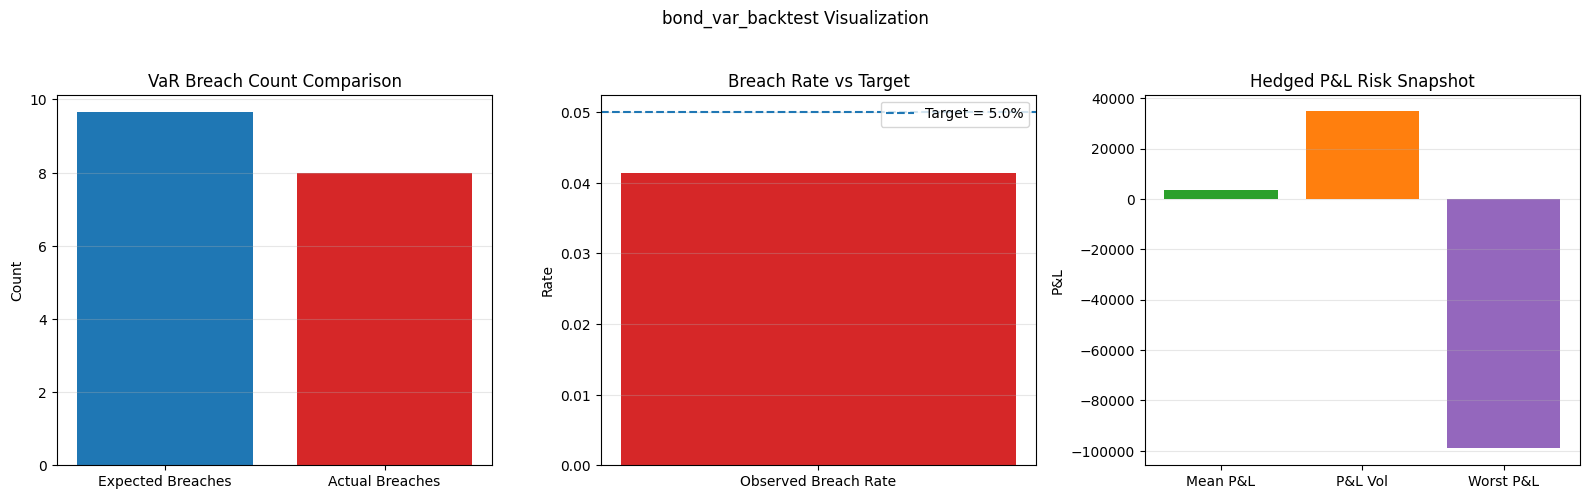

,Value
Backtest Window,193.0000
VaR Confidence,0.9500
Rolling Window,60.0000
Expected Breaches,9.6500
Actual Breaches,8.0000
Breach Ratio,0.0415
Mean Hedged EOD P&L,"3,350.2695"
Hedged P&L Volatility,"34,747.8462"
Worst Hedged EOD P&L,"-99,135.9782"


In [45]:
metrics_to_plot = [
    'Expected Breaches',
    'Actual Breaches',
    'Breach Ratio',
    'Mean Hedged EOD P&L',
    'Hedged P&L Volatility',
    'Worst Hedged EOD P&L'
 ]

viz_data = bond_var_backtest[metrics_to_plot].astype(float)
target_breach_rate = 1 - var_confidence

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].bar(
    ['Expected Breaches', 'Actual Breaches'],
    [viz_data['Expected Breaches'], viz_data['Actual Breaches']],
    color=['tab:blue', 'tab:red']
 )
axes[0].set_title('VaR Breach Count Comparison')
axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(
    ['Observed Breach Rate'],
    [viz_data['Breach Ratio']],
    color='tab:red'
 )
axes[1].axhline(target_breach_rate, color='tab:blue', linestyle='--', label=f'Target = {target_breach_rate:.1%}')
axes[1].set_title('Breach Rate vs Target')
axes[1].set_ylabel('Rate')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(
    ['Mean P&L', 'P&L Vol', 'Worst P&L'],
    [
        viz_data['Mean Hedged EOD P&L'],
        viz_data['Hedged P&L Volatility'],
        viz_data['Worst Hedged EOD P&L']
    ],
    color=['tab:green', 'tab:orange', 'tab:purple']
 )
axes[2].set_title('Hedged P&L Risk Snapshot')
axes[2].set_ylabel('P&L')
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('bond_var_backtest Visualization', y=1.03)
plt.tight_layout()
plt.show()

bond_var_backtest.to_frame('Value').style.format('{:,.4f}')

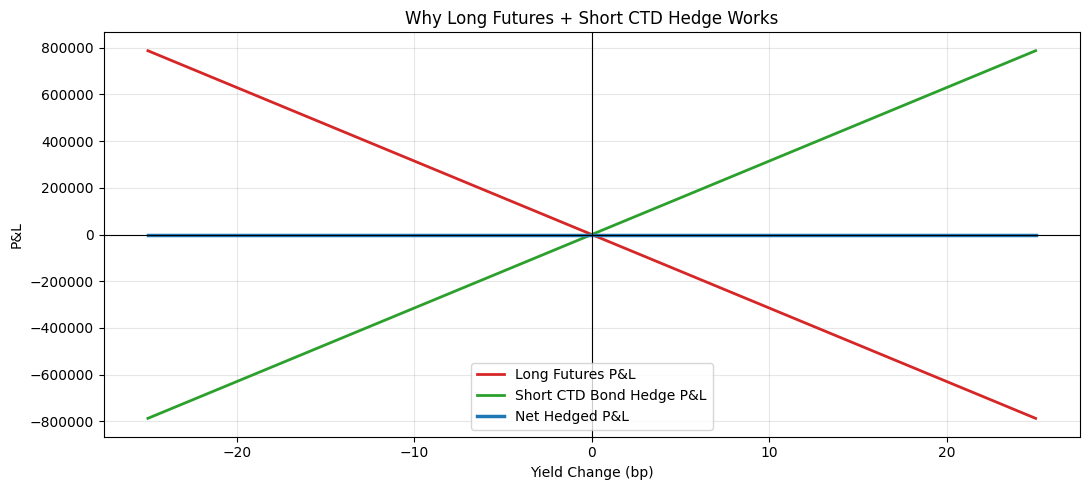

Interpretation: when yields rise (right side), long futures P&L declines, while the short CTD hedge rises; the net hedged line is flatter, showing reduced rate sensitivity.


In [53]:
yield_axis_bp = np.linspace(-25, 25, 101)

# Long futures lose when yields rise (negative DV01 exposure).
pnl_long_futures = -portfolio_dv01 * yield_axis_bp

# Short CTD hedge gains when yields rise and offsets part of futures sensitivity.
pnl_short_ctd = ctd_hedge_notional_mm * ctd_bond_dv01_per_1mm * yield_axis_bp

pnl_net_hedged = pnl_long_futures + pnl_short_ctd

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yield_axis_bp, pnl_long_futures, label='Long Futures P&L', linewidth=2, color='tab:red')
ax.plot(yield_axis_bp, pnl_short_ctd, label='Short CTD Bond Hedge P&L', linewidth=2, color='tab:green')
ax.plot(yield_axis_bp, pnl_net_hedged, label='Net Hedged P&L', linewidth=2.5, color='tab:blue')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Why Long Futures + Short CTD Hedge Works')
ax.set_xlabel('Yield Change (bp)')
ax.set_ylabel('P&L')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    'Interpretation: when yields rise (right side), long futures P&L declines, while the short CTD hedge rises; the net hedged line is flatter, showing reduced rate sensitivity.'
)

**How to interpret this hedge-intuition graph**

1. **Long Futures P&L (red):** downward slope. As yields rise (move right), futures prices fall, so a long futures position loses money.
2. **Short CTD Bond Hedge P&L (green):** upward slope. A short CTD bond position gains when yields rise, offsetting futures losses.
3. **Net Hedged P&L (blue):** near-flat around zero. With DV01-matched sizing, first-order parallel rate sensitivity is mostly neutralized.

**Key takeaway:** the hedge removes most parallel-yield risk, but in practice the net line is rarely perfectly flat because of basis risk, convexity mismatch, CTD switch risk, and roll effects.

The backtest compares realized hedged losses with a rolling Historical $95\%$ VaR estimated from the previous 60 business days of simulated EOD P&L. The diagnostic charts below separate two questions:


- VaR construction quality: does the rolling loss distribution and quantile threshold look stable and economically reasonable?


- Backtesting quality: are breach frequency and timing consistent with the expected $5\%$ exception rate, or do we see clustering and regime drift?


How to interpret each diagnostic in practice:


1. VaR construction quality


- Loss definition and quantile setup should be internally consistent: $L_t=-PnL_t^{H}$ and $VaR_{\alpha,t}=Q_{\alpha}(L_{t-w+1},\ldots,L_t)$.


- The rolling VaR threshold should move with market risk: it should rise when loss dispersion increases and ease when conditions stabilize.


- Stability check: the VaR line should not be excessively jumpy day to day unless there is a clear regime shock.


- Economic reasonableness: VaR magnitude should be on the same order as observed hedged-loss tails, not systematically too small or implausibly large.


2. Backtesting quality


- Frequency calibration: with $\alpha=95\%$, expected breach rate is $1-\alpha=5\%$. Observed breach rate is $\hat p=\frac{1}{T}\sum I_t$, where $I_t=\mathbb{1}(L_t>VaR_t)$.


- If $\hat p$ is materially above $5\%$, risk is likely understated. If far below $5\%$ for long periods, VaR may be conservative.


- Timing calibration: breaches should be relatively dispersed. Persistent clustering indicates regime change, volatility state shifts, or model misspecification.


- Regime drift test: monitor rolling breach rate versus target and governance thresholds. Sustained elevation above target is a warning that model calibration is deteriorating in the active regime.

In [47]:
from IPython.display import Markdown, display

display(
    Markdown(
        f"**Takeaway:** Expected breaches = **{expected_breaches:.2f}**, actual breaches = **{actual_breaches}**, and observed breach ratio = **{breach_ratio:.2%}** (target **{(1 - var_confidence):.2%}**)."
    )
)

**Takeaway:** Expected breaches = **9.65**, actual breaches = **8**, and observed breach ratio = **4.15%** (target **5.00%**).

### Formula Summary: EOD P&L, Historical VaR, and Backtesting


This section summarizes the exact formulas used in the bond-futures portfolio hedged with the CTD bond.


Position setup (DV01-based):


- Futures portfolio DV01: $DV01_{F,port} = N_F \times DV01_F$
- CTD hedge notional (in million units): $Notional_{CTD} = \frac{DV01_{F,port}}{DV01_{CTD,1mm}}$


Daily rate moves and basis:


- CTD yield change (bp): $\Delta y_t$
- Futures yield change (bp): $\Delta y^{F}_t = \Delta y_t + b_t$
- $b_t$ is basis noise


EOD realized P&L decomposition:


- Futures portfolio P&L: $PnL^{F}_t = -DV01_{F,port} \cdot \Delta y^{F}_t$
- CTD hedge P&L (short CTD bond hedge): $PnL^{CTD}_t = Notional_{CTD} \cdot DV01_{CTD,1mm} \cdot \Delta y_t$
- Residual basis/curve term: $PnL^{res}_t = \lambda \cdot DV01_{F,port} \cdot b_t$
- Total hedged P&L: $PnL^{H}_t = PnL^{F}_t + PnL^{CTD}_t + PnL^{res}_t$


Loss transformation for risk measurement:


- Realized loss: $L_t = -PnL^{H}_t$


Historical VaR (rolling window):


- For confidence level $\alpha$ and window $w$:
  $VaR_{\alpha,t} = Q_{\alpha}(L_{t-w+1}, \ldots, L_t)$


Backtesting rule (exception test):


- Breach indicator: $I_t = \mathbb{1}(L_t > VaR_{\alpha,t})$
- Observed breach rate: $\hat{p} = \frac{1}{T}\sum_{t=1}^{T} I_t$
- Expected breach rate under model: $p^* = 1 - \alpha$
- Expected breach count: $T(1-\alpha)$


Operational alert thresholds used later in the notebook (one-sided, high-breach monitoring):


- AMBER if rolling breach rate $> 7\%$ for more than $N$ consecutive days
- RED if rolling breach rate $> 10\%$ for more than $N$ consecutive days

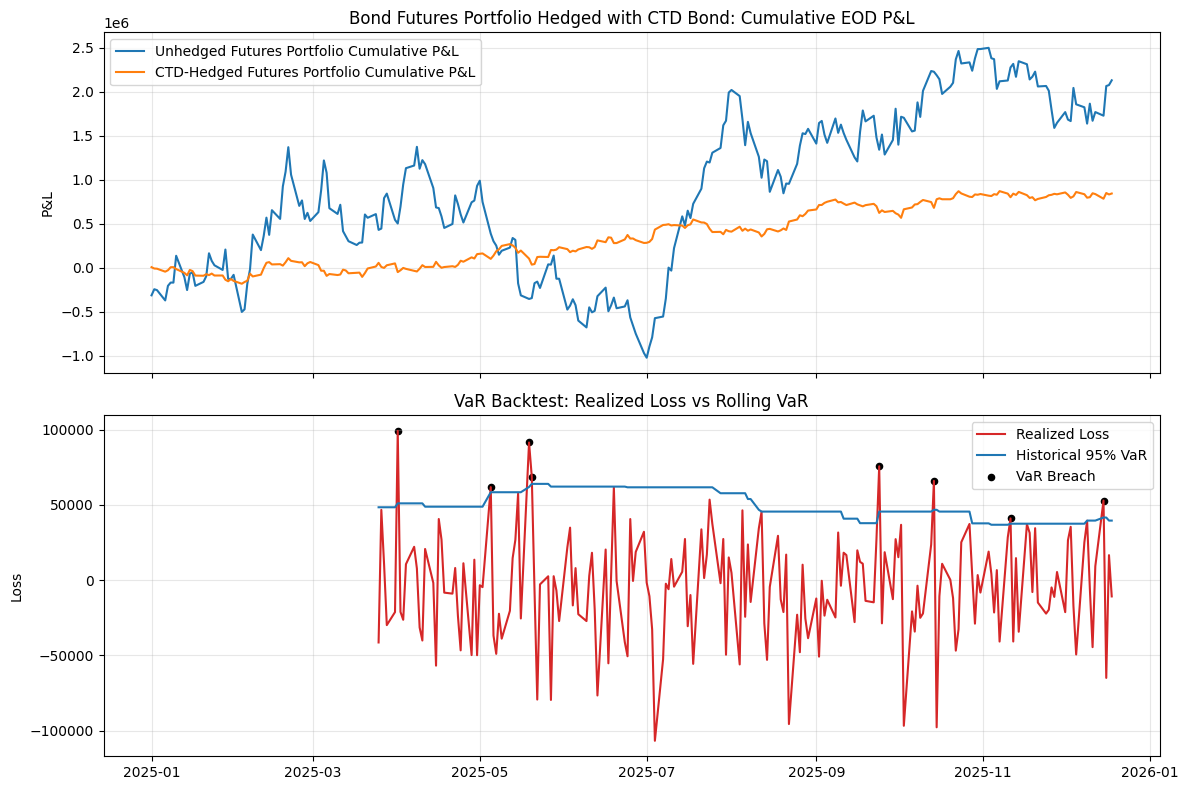

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


axes[0].plot(
    bond_hedge_sim.index,
    bond_hedge_sim['cum_futures_portfolio_pnl'],
    label='Unhedged Futures Portfolio Cumulative P&L'
 )
axes[0].plot(
    bond_hedge_sim.index,
    bond_hedge_sim['cum_hedged_bond_pnl'],
    label='CTD-Hedged Futures Portfolio Cumulative P&L'
 )
axes[0].set_title('Bond Futures Portfolio Hedged with CTD Bond: Cumulative EOD P&L')
axes[0].set_ylabel('P&L')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(
    backtesting_sample.index,
    backtesting_sample['loss'],
    label='Realized Loss',
    color='tab:red'
 )
axes[1].plot(
    backtesting_sample.index,
    backtesting_sample['historical_var_95'],
    label='Historical 95% VaR',
    color='tab:blue'
 )
breaches = backtesting_sample[backtesting_sample['var_breach']]
axes[1].scatter(
    breaches.index,
    breaches['loss'],
    color='black',
    s=20,
    label='VaR Breach'
 )
axes[1].set_title('VaR Backtest: Realized Loss vs Rolling VaR')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

#### Advanced Action Pack: Traffic-Light Monitoring, Rolling Metrics, CTD-Switch, and Stress Tests


The following diagnostics operationalize the risk controls proposed earlier:


- traffic-light status for VaR calibration monitoring
- rolling hedge-effectiveness metrics
- CTD-switch scenario with and without hedge recalibration
- stress tests for VaR window length and basis-volatility regimes

,Value
Target Breach Rate,0.05
Observed Breach Rate,0.041451
Expected Breaches,9.65
Actual Breaches,8
Traffic Light,GREEN


,VaR Window,Breach Rate,Traffic Light
0,40,0.046948,GREEN
1,60,0.041451,GREEN
2,120,0.030075,GREEN


,Basis Sigma (bp),Breach Rate,Traffic Light,Hedged Volatility
0,0.80,0.041451,GREEN,22158.943207
1,1.25,0.051813,GREEN,35018.150070
2,2.00,0.041451,GREEN,58826.927471


,Scenario,Breach Rate,Traffic Light,P&L Volatility
0,base_no_switch,0.041451,GREEN,34747.846226
1,stale_switch,0.051813,GREEN,40591.663172
2,dynamic_switch,0.041451,GREEN,34747.846226


,Alert,Note
0,None,No AMBER/RED high-breach streaks longer than t...


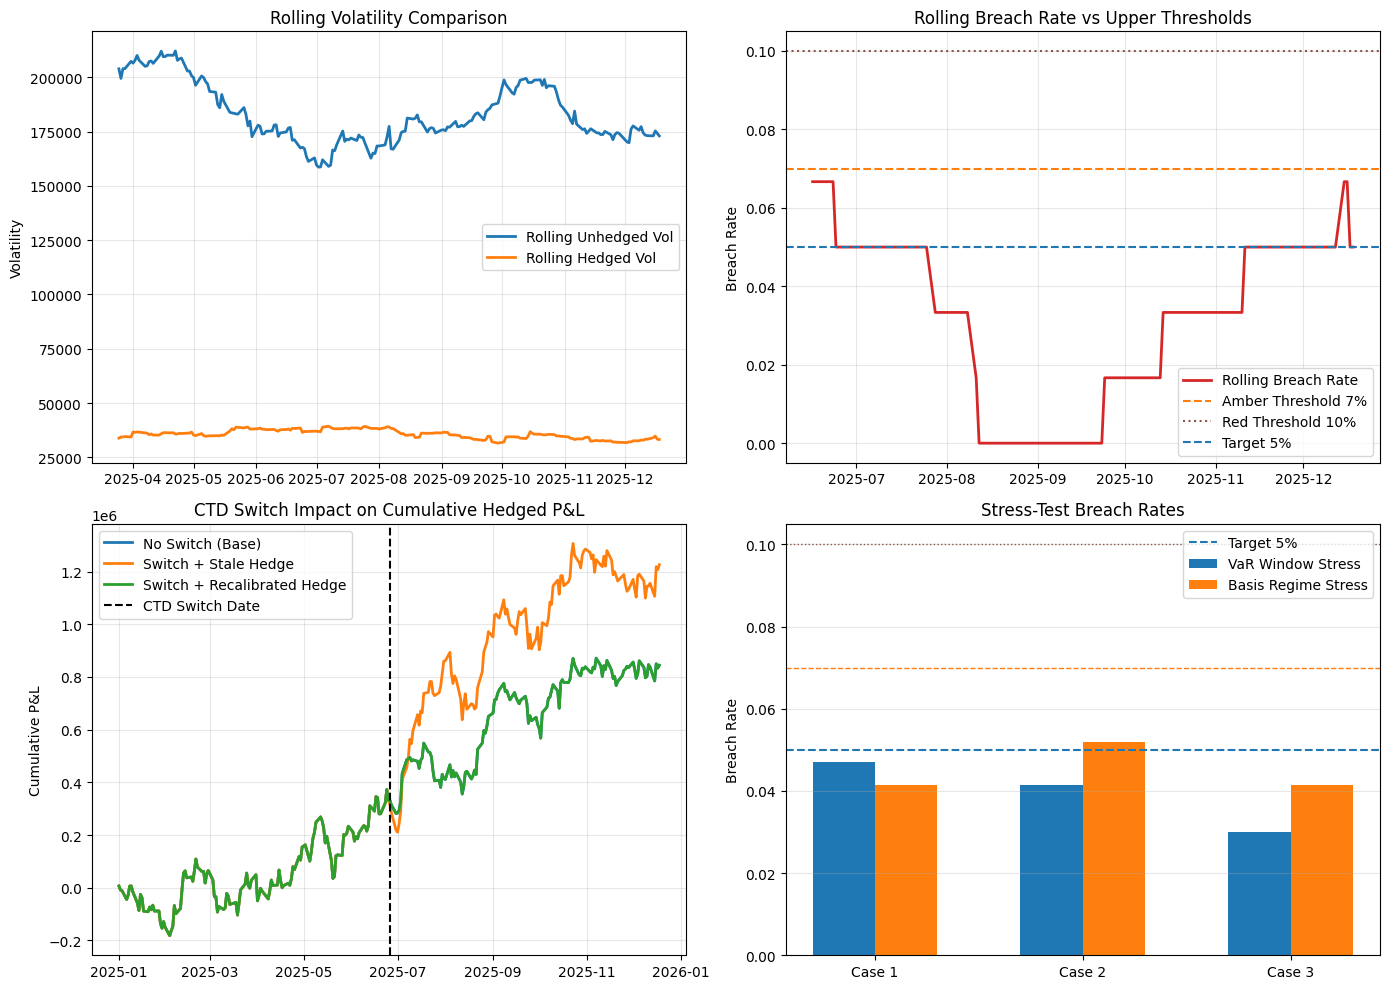

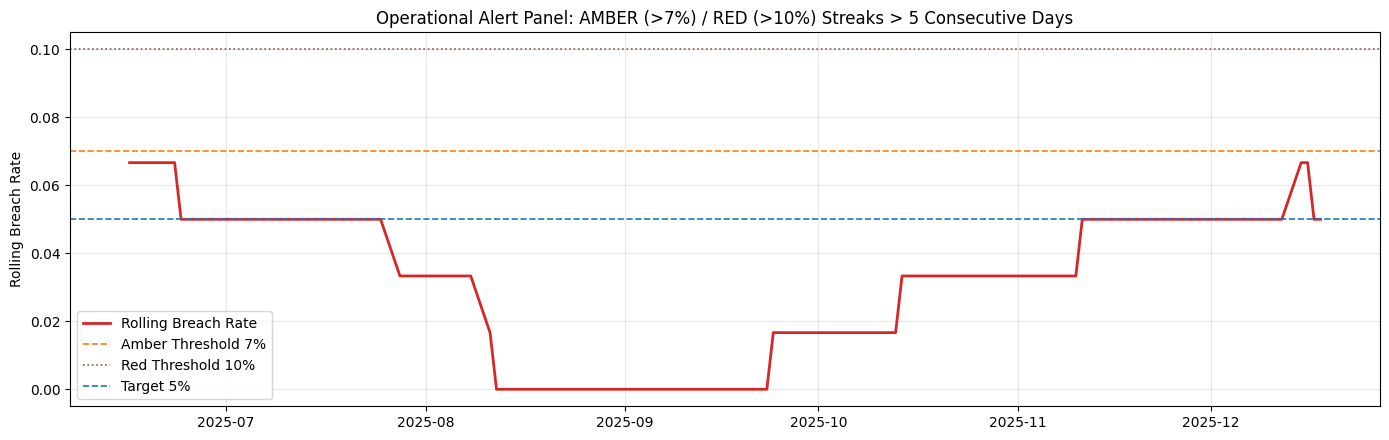

In [49]:
def traffic_light_status(breach_ratio, amber_threshold=0.07, red_threshold=0.10):
    if breach_ratio > red_threshold:
        return 'RED'
    if breach_ratio > amber_threshold:
        return 'AMBER'
    return 'GREEN'

def historical_var_backtest_from_loss(loss_series, window, alpha=0.95):
    var_series = loss_series.rolling(window).quantile(alpha)
    valid = pd.DataFrame({'loss': loss_series, 'var': var_series}).dropna()
    breaches = valid['loss'] > valid['var']
    return {
        'var_series': var_series,
        'valid': valid,
        'breaches': breaches,
        'breach_rate': breaches.mean(),
        'expected_breaches': len(valid) * (1 - alpha),
        'actual_breaches': int(breaches.sum())
    }

def extract_consecutive_alerts(rate_series, min_days=5, amber_threshold=0.07, red_threshold=0.10):
    def classify(rate):
        if pd.isna(rate):
            return None
        if rate > red_threshold:
            return 'RED'
        if rate > amber_threshold:
            return 'AMBER'
        return None

    alerts = []
    current_status = None
    start_idx = None
    streak = 0
    prev_idx = None

    for idx, rate in rate_series.items():
        status = classify(rate)

        if status is not None:
            if status == current_status:
                streak += 1
            else:
                if current_status is not None and streak > min_days:
                    alerts.append(
                        {
                            'Alert': current_status,
                            'Start': start_idx,
                            'End': prev_idx,
                            'Consecutive Days': streak
                        }
                    )
                current_status = status
                start_idx = idx
                streak = 1
        else:
            if current_status is not None and streak > min_days:
                alerts.append(
                    {
                        'Alert': current_status,
                        'Start': start_idx,
                        'End': prev_idx,
                        'Consecutive Days': streak
                    }
                )
            current_status = None
            start_idx = None
            streak = 0

        prev_idx = idx

    if current_status is not None and streak > min_days:
        alerts.append(
            {
                'Alert': current_status,
                'Start': start_idx,
                'End': prev_idx,
                'Consecutive Days': streak
            }
        )

    return pd.DataFrame(alerts)

# 1) Traffic-light summary for the current base case
base_backtest = historical_var_backtest_from_loss(bond_hedge_sim['loss'], var_window, var_confidence)
traffic_status = traffic_light_status(base_backtest['breach_rate'])
var_governance = pd.Series(
    {
        'Target Breach Rate': 1 - var_confidence,
        'Observed Breach Rate': base_backtest['breach_rate'],
        'Expected Breaches': base_backtest['expected_breaches'],
        'Actual Breaches': base_backtest['actual_breaches'],
        'Traffic Light': traffic_status
    }
)

# 2) Rolling hedge-effectiveness diagnostics
rolling_window = 60
bond_hedge_sim['rolling_unhedged_vol'] = bond_hedge_sim['futures_portfolio_pnl'].rolling(rolling_window).std()
bond_hedge_sim['rolling_hedged_vol'] = bond_hedge_sim['hedged_bond_pnl'].rolling(rolling_window).std()
bond_hedge_sim['rolling_vol_reduction_pct'] = 100 * (
    1 - bond_hedge_sim['rolling_hedged_vol'] / bond_hedge_sim['rolling_unhedged_vol']
)
bond_hedge_sim['rolling_breach_rate'] = base_backtest['breaches'].astype(float).rolling(rolling_window).mean().reindex(bond_hedge_sim.index)

alert_min_consecutive_days = 5
amber_threshold = 0.07
red_threshold = 0.10
rolling_alerts_df = extract_consecutive_alerts(
    bond_hedge_sim['rolling_breach_rate'].dropna(),
    min_days=alert_min_consecutive_days,
    amber_threshold=amber_threshold,
    red_threshold=red_threshold
)

# 3) CTD-switch scenario: stale hedge vs recalibrated hedge
switch_day = bond_hedge_days // 2
ctd_dv01_pre = ctd_bond_dv01_per_1mm
ctd_dv01_post = int(ctd_bond_dv01_per_1mm * 0.82)
ctd_dv01_series = np.where(
    np.arange(bond_hedge_days) < switch_day,
    ctd_dv01_pre,
    ctd_dv01_post
)

fixed_ctd_notional = futures_portfolio_dv01 / ctd_dv01_pre
dynamic_ctd_notional = futures_portfolio_dv01 / ctd_dv01_series

stale_ctd_hedge_pnl = fixed_ctd_notional * ctd_dv01_series * yield_change_bp
dynamic_ctd_hedge_pnl = dynamic_ctd_notional * ctd_dv01_series * yield_change_bp

hedged_pnl_stale_switch = futures_portfolio_pnl + stale_ctd_hedge_pnl + residual_pnl
hedged_pnl_dynamic_switch = futures_portfolio_pnl + dynamic_ctd_hedge_pnl + residual_pnl

ctd_switch_df = pd.DataFrame(
    {
        'hedged_pnl_base_no_switch': bond_hedge_sim['hedged_bond_pnl'].values,
        'hedged_pnl_stale_switch': hedged_pnl_stale_switch,
        'hedged_pnl_dynamic_switch': hedged_pnl_dynamic_switch
    },
    index=bond_dates
)

switch_backtest = []
for col in ['hedged_pnl_base_no_switch', 'hedged_pnl_stale_switch', 'hedged_pnl_dynamic_switch']:
    loss_series = -ctd_switch_df[col]
    bt = historical_var_backtest_from_loss(loss_series, var_window, var_confidence)
    ctd_switch_df[f'loss_{col}'] = loss_series
    ctd_switch_df[f'var_{col}'] = bt['var_series']
    ctd_switch_df[f'breach_{col}'] = False
    ctd_switch_df.loc[bt['valid'].index, f'breach_{col}'] = bt['breaches'].values
    switch_backtest.append(
        {
            'Scenario': col.replace('hedged_pnl_', ''),
            'Breach Rate': bt['breach_rate'],
            'Traffic Light': traffic_light_status(bt['breach_rate'], amber_threshold, red_threshold),
            'P&L Volatility': ctd_switch_df[col].std()
        }
    )
switch_backtest_df = pd.DataFrame(switch_backtest)

# 4) Stress tests: VaR window and basis-vol regimes
window_results = []
for w in [40, 60, 120]:
    bt = historical_var_backtest_from_loss(bond_hedge_sim['loss'], w, var_confidence)
    window_results.append(
        {
            'VaR Window': w,
            'Breach Rate': bt['breach_rate'],
            'Traffic Light': traffic_light_status(bt['breach_rate'], amber_threshold, red_threshold)
        }
    )
window_stress_df = pd.DataFrame(window_results)

basis_regimes = [0.8, 1.25, 2.0]
basis_results = []
for bs in basis_regimes:
    np.random.seed(100 + int(bs * 100))
    regime_basis_noise = np.random.normal(0.0, bs, bond_hedge_days)
    regime_futures_yield = yield_change_bp + regime_basis_noise
    regime_futures_pnl = -portfolio_dv01 * regime_futures_yield
    regime_residual = residual_scale * portfolio_dv01 * regime_basis_noise
    regime_hedged_pnl = regime_futures_pnl + ctd_bond_hedge_pnl + regime_residual
    regime_loss = pd.Series(-regime_hedged_pnl, index=bond_dates)
    bt = historical_var_backtest_from_loss(regime_loss, var_window, var_confidence)
    basis_results.append(
        {
            'Basis Sigma (bp)': bs,
            'Breach Rate': bt['breach_rate'],
            'Traffic Light': traffic_light_status(bt['breach_rate'], amber_threshold, red_threshold),
            'Hedged Volatility': np.std(regime_hedged_pnl)
        }
    )
basis_stress_df = pd.DataFrame(basis_results)

# Report tables
display(var_governance.to_frame('Value'))
display(window_stress_df)
display(basis_stress_df)
display(switch_backtest_df)
display(rolling_alerts_df if not rolling_alerts_df.empty else pd.DataFrame({'Alert': ['None'], 'Note': ['No AMBER/RED high-breach streaks longer than threshold']}))

# Visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    bond_hedge_sim.index,
    bond_hedge_sim['rolling_unhedged_vol'],
    label='Rolling Unhedged Vol',
    linewidth=2
)
axes[0, 0].plot(
    bond_hedge_sim.index,
    bond_hedge_sim['rolling_hedged_vol'],
    label='Rolling Hedged Vol',
    linewidth=2
)
axes[0, 0].set_title('Rolling Volatility Comparison')
axes[0, 0].set_ylabel('Volatility')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(
    bond_hedge_sim.index,
    bond_hedge_sim['rolling_breach_rate'],
    label='Rolling Breach Rate',
    color='tab:red',
    linewidth=2
)
axes[0, 1].axhline(amber_threshold, color='tab:orange', linestyle='--', label='Amber Threshold 7%')
axes[0, 1].axhline(red_threshold, color='tab:brown', linestyle=':', label='Red Threshold 10%')
axes[0, 1].axhline(1 - var_confidence, color='tab:blue', linestyle='--', label='Target 5%')
axes[0, 1].set_title('Rolling Breach Rate vs Upper Thresholds')
axes[0, 1].set_ylabel('Breach Rate')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(
    ctd_switch_df.index,
    ctd_switch_df['hedged_pnl_base_no_switch'].cumsum(),
    label='No Switch (Base)',
    linewidth=2
)
axes[1, 0].plot(
    ctd_switch_df.index,
    ctd_switch_df['hedged_pnl_stale_switch'].cumsum(),
    label='Switch + Stale Hedge',
    linewidth=2
)
axes[1, 0].plot(
    ctd_switch_df.index,
    ctd_switch_df['hedged_pnl_dynamic_switch'].cumsum(),
    label='Switch + Recalibrated Hedge',
    linewidth=2
)
axes[1, 0].axvline(ctd_switch_df.index[switch_day], color='black', linestyle='--', label='CTD Switch Date')
axes[1, 0].set_title('CTD Switch Impact on Cumulative Hedged P&L')
axes[1, 0].set_ylabel('Cumulative P&L')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

x_pos = np.arange(len(window_stress_df))
axes[1, 1].bar(x_pos - 0.15, window_stress_df['Breach Rate'], width=0.3, label='VaR Window Stress')
axes[1, 1].bar(x_pos + 0.15, basis_stress_df['Breach Rate'][:len(x_pos)], width=0.3, label='Basis Regime Stress')
axes[1, 1].axhline(1 - var_confidence, color='tab:blue', linestyle='--', label='Target 5%')
axes[1, 1].axhline(amber_threshold, color='tab:orange', linestyle='--', linewidth=1)
axes[1, 1].axhline(red_threshold, color='tab:brown', linestyle=':', linewidth=1)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([f'Case {i+1}' for i in range(len(x_pos))])
axes[1, 1].set_title('Stress-Test Breach Rates')
axes[1, 1].set_ylabel('Breach Rate')
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional operational alert panel
fig, ax = plt.subplots(figsize=(14, 4.5))
roll_series = bond_hedge_sim['rolling_breach_rate'].dropna()
ax.plot(roll_series.index, roll_series, color='tab:red', linewidth=2, label='Rolling Breach Rate')
ax.axhline(amber_threshold, color='tab:orange', linestyle='--', linewidth=1.2, label='Amber Threshold 7%')
ax.axhline(red_threshold, color='tab:brown', linestyle=':', linewidth=1.2, label='Red Threshold 10%')
ax.axhline(1 - var_confidence, color='tab:blue', linestyle='--', linewidth=1.2, label='Target 5%')

if not rolling_alerts_df.empty:
    for _, row in rolling_alerts_df.iterrows():
        color = 'red' if row['Alert'] == 'RED' else 'orange'
        ax.axvspan(row['Start'], row['End'], color=color, alpha=0.2)

ax.set_title(
    f'Operational Alert Panel: AMBER (>7%) / RED (>10%) Streaks > {alert_min_consecutive_days} Consecutive Days'
 )
ax.set_ylabel('Rolling Breach Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Commodities

Commodity producers and consumers often hedge with futures. For example, a wheat producer may short wheat futures to lock in a future sale price.

The hedge may be imperfect if the grade, delivery location, or delivery month differs from the actual underlying commodity exposure. This difference is often called basis risk.

In [ ]:
examples = pd.DataFrame(
    {
        'Asset Class': ['Equities', 'FX', 'Rates', 'Bond Futures', 'Commodities'],
        'Typical Hedge Instrument': [
            'Index futures',
            'FX forwards',
            'Rates futures or swaps',
            'Treasury bond futures',
            'Commodity futures'
        ],
        'Primary Risk': [
            'Market beta',
            'Exchange rate',
            'Yield changes',
            'Duration or DV01',
            'Price changes'
        ],
        'Perfect Hedge Possible?': ['Rare', 'Sometimes', 'Rare', 'Rare', 'Rare']
    }
)
examples

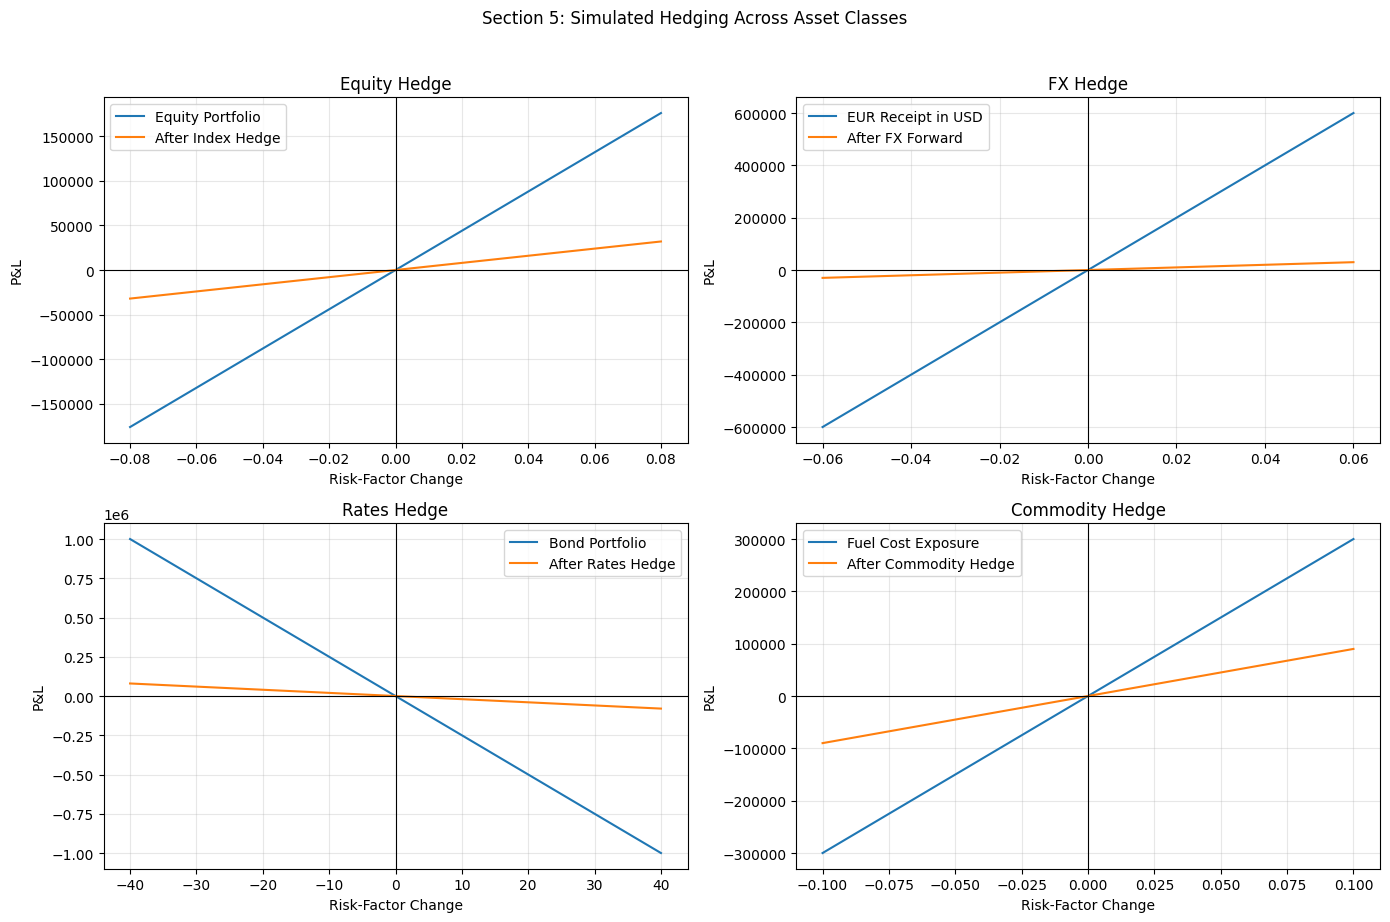

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))


equity_move = np.linspace(-0.08, 0.08, 150)
axes[0, 0].plot(equity_move, 2_000_000 * (1.1 * equity_move), label='Equity Portfolio')
axes[0, 0].plot(equity_move, 2_000_000 * (1.1 * equity_move - 0.9 * equity_move), label='After Index Hedge')
axes[0, 0].set_title('Equity Hedge')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)


fx_move = np.linspace(-0.06, 0.06, 150)
axes[0, 1].plot(fx_move, 10_000_000 * fx_move, label='EUR Receipt in USD')
axes[0, 1].plot(fx_move, 10_000_000 * (fx_move - 0.95 * fx_move), label='After FX Forward')
axes[0, 1].set_title('FX Hedge')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)


rate_move = np.linspace(-40, 40, 150)
axes[1, 0].plot(rate_move, -25_000 * rate_move, label='Bond Portfolio')
axes[1, 0].plot(rate_move, -25_000 * rate_move + 23_000 * rate_move, label='After Rates Hedge')
axes[1, 0].set_title('Rates Hedge')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)


commodity_move = np.linspace(-0.10, 0.10, 150)
axes[1, 1].plot(commodity_move, 3_000_000 * commodity_move, label='Fuel Cost Exposure')
axes[1, 1].plot(commodity_move, 3_000_000 * (commodity_move - 0.7 * commodity_move), label='After Commodity Hedge')
axes[1, 1].set_title('Commodity Hedge')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)


for ax in axes.flat:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Risk-Factor Change')
    ax.set_ylabel('P&L')


plt.suptitle('Section 5: Simulated Hedging Across Asset Classes', y=1.02)
plt.tight_layout()
plt.show()

## 6. Simulated Hedge Dataset


Rather than using a single static price change, we can simulate a year of correlated daily spot and futures returns. This gives us a more realistic way to study hedge effectiveness, residual risk, and how hedged and unhedged P&L evolve over time.

In [3]:
np.random.seed(42)


n_days = 252
rho = 0.90
sigma_spot = 0.014
sigma_futures = 0.012
mu_spot = 0.0004
mu_futures = 0.0003
initial_spot = 100.0
initial_futures = 100.0
exposure = 1_000_000


cov_matrix = np.array(
    [
        [sigma_spot ** 2, rho * sigma_spot * sigma_futures],
        [rho * sigma_spot * sigma_futures, sigma_futures ** 2]
    ]
)


simulated_returns = np.random.multivariate_normal(
    mean=[mu_spot, mu_futures],
    cov=cov_matrix,
    size=n_days
)


hedge_ratio = minimum_variance_hedge_ratio(rho, sigma_spot, sigma_futures)
dates = pd.date_range('2025-01-01', periods=n_days, freq='B')


sim_data = pd.DataFrame(
    simulated_returns,
    columns=['spot_return', 'futures_return'],
    index=dates
)


sim_data['spot_price'] = initial_spot * (1 + sim_data['spot_return']).cumprod()
sim_data['futures_price'] = initial_futures * (1 + sim_data['futures_return']).cumprod()


sim_data['unhedged_pnl'] = exposure * sim_data['spot_return']
sim_data['hedged_pnl'] = exposure * (sim_data['spot_return'] - hedge_ratio * sim_data['futures_return'])
sim_data['cum_unhedged_pnl'] = sim_data['unhedged_pnl'].cumsum()
sim_data['cum_hedged_pnl'] = sim_data['hedged_pnl'].cumsum()


sim_data[['spot_return', 'futures_return', 'spot_price', 'futures_price', 'unhedged_pnl', 'hedged_pnl']].head()

,spot_return,futures_return,spot_price,futures_price,unhedged_pnl,hedged_pnl
2025-01-01,-0.006068,-0.005887,99.393205,99.411307,-6067.952751,113.326940
2025-01-02,-0.012503,-0.002464,98.150453,99.166384,-12503.391771,-9916.475876
2025-01-03,0.004234,0.002285,98.566064,99.392935,4234.430296,1835.644565
2025-01-06,-0.023331,-0.015612,96.266427,97.841225,-23330.923491,-6938.448666
2025-01-07,0.005432,0.007430,96.789392,98.568197,5432.477600,-2369.153592


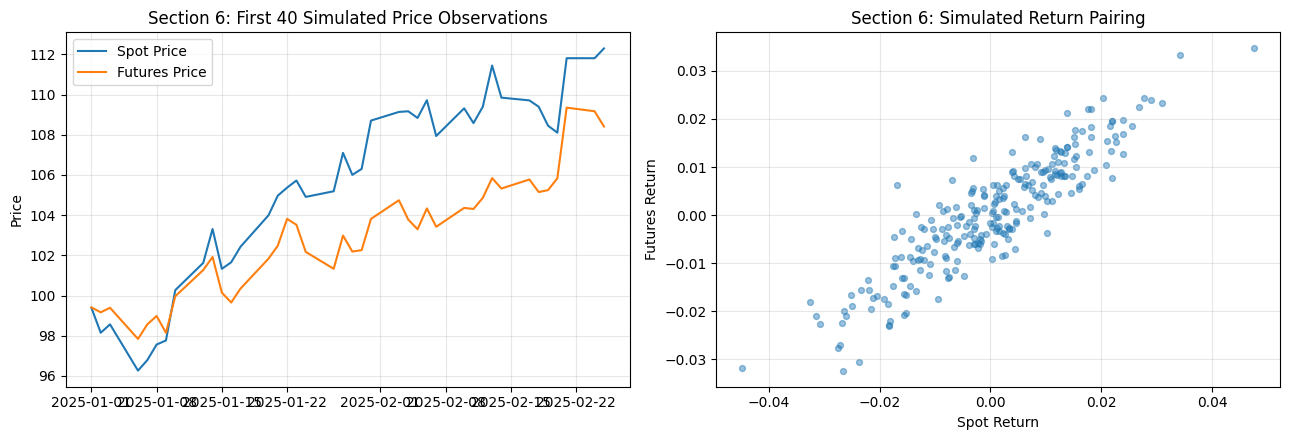

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))


preview_window = sim_data.iloc[:40]
axes[0].plot(preview_window.index, preview_window['spot_price'], label='Spot Price')
axes[0].plot(preview_window.index, preview_window['futures_price'], label='Futures Price')
axes[0].set_title('Section 6: First 40 Simulated Price Observations')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].scatter(sim_data['spot_return'], sim_data['futures_return'], alpha=0.45, s=18)
axes[1].set_title('Section 6: Simulated Return Pairing')
axes[1].set_xlabel('Spot Return')
axes[1].set_ylabel('Futures Return')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

The simulated series uses a high, but not perfect, spot-futures correlation. That means the hedge should reduce dispersion in daily P&L without removing risk completely. The gap between those two outcomes is the practical difference between a strong hedge and a perfect hedge.

## 7. Risk Comparison




Once we have simulated daily P&L, we can compare the unhedged and hedged positions using basic risk metrics. A good hedge should usually lower volatility, reduce tail loss, and improve drawdown behavior, even if it does not eliminate losses entirely.

### Variance Basics




Variance measures how widely returns or P&L move around their average value. A larger variance means outcomes are more spread out, so the position is less predictable and typically riskier. If $r_1, r_2, \ldots, r_n$ are returns with sample mean $\bar{r}$, the sample variance is:




$\mathrm{Var}(r) = \frac{1}{n-1}\sum_{i=1}^{n}(r_i - \bar{r})^2$




Because variance is measured in squared units, practitioners often look at standard deviation, which is just $\sqrt{\mathrm{Var}(r)}$. Standard deviation is easier to interpret because it is expressed in the same units as the underlying return or P&L series. In hedging, the core idea is simple: if the hedge works, the variance of the combined position should fall relative to the unhedged exposure. If it does not fall, the hedge is either weak, mismatched, or incorrectly sized. 




Practical examples:




- Equity index hedge: a long equity portfolio may have large day-to-day P&L variance driven by market beta. Short index futures should reduce that variance if the portfolio beta is estimated reasonably well.
- FX hedge: a firm expecting foreign-currency revenue may use forwards to reduce the variance of domestic-currency cash flows. The closer the hedge maturity and notional are to the actual receipt, the stronger the reduction in variance.
- Interest-rate hedge: a bond portfolio manager may use Treasury futures or swaps to reduce the variance of portfolio value caused by rate moves. The hedge can still leave residual variance if different parts of the yield curve move by different amounts.
- Commodity hedge: an airline can hedge fuel costs with energy derivatives. Variance may fall materially, but basis risk remains if the derivative does not match the exact fuel grade or delivery point.


The table below compares the two simulated strategies on day-to-day volatility, tail losses, and drawdown. Those metrics make it easier to see whether the hedge is only smoothing noise or materially improving downside risk.

In [4]:
def expected_shortfall(pnl_series, alpha=0.95):
    cutoff = pnl_series.quantile(1 - alpha)
    return pnl_series[pnl_series <= cutoff].mean()


def max_drawdown(cumulative_pnl):
    running_peak = cumulative_pnl.cummax()
    drawdown = cumulative_pnl - running_peak
    return drawdown.min()


risk_summary = pd.DataFrame(
    {
        'Unhedged': [
            sim_data['unhedged_pnl'].std(),
            sim_data['unhedged_pnl'].quantile(0.05),
            expected_shortfall(sim_data['unhedged_pnl']),
            max_drawdown(sim_data['cum_unhedged_pnl'])
        ],
        'Hedged': [
            sim_data['hedged_pnl'].std(),
            sim_data['hedged_pnl'].quantile(0.05),
            expected_shortfall(sim_data['hedged_pnl']),
            max_drawdown(sim_data['cum_hedged_pnl'])
        ]
    },
    index=['Daily Volatility', '95% VaR', '95% Expected Shortfall', 'Max Drawdown']
)


risk_summary.style.format('{:,.2f}')

,Unhedged,Hedged
Daily Volatility,"14,016.36","5,958.16"
95% VaR,"-23,546.93","-9,650.08"
95% Expected Shortfall,"-28,773.84","-13,016.57"
Max Drawdown,"-237,251.92","-110,072.80"


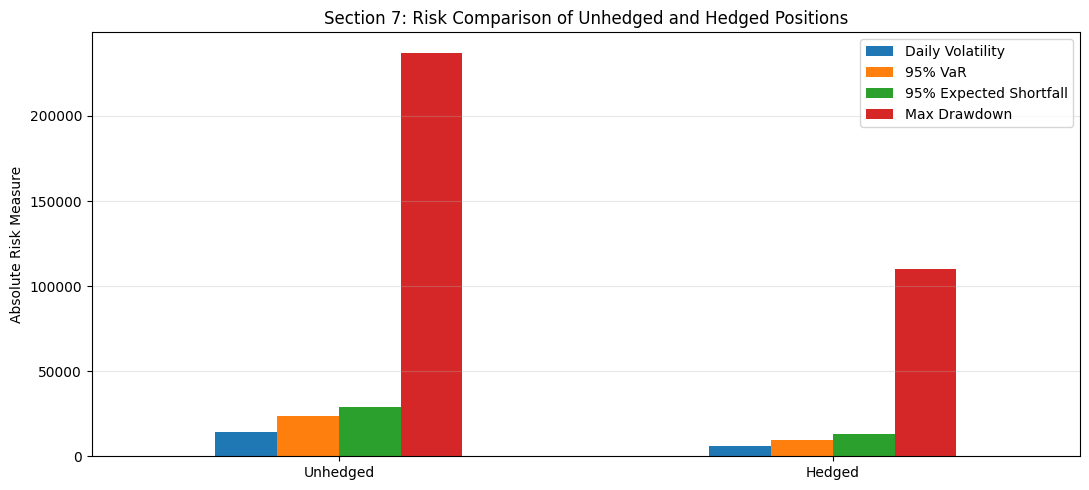

In [17]:
risk_display = risk_summary.copy()
risk_display.loc[['95% VaR', '95% Expected Shortfall', 'Max Drawdown']] *= -1


ax = risk_display.T.plot(kind='bar', figsize=(11, 5))
ax.set_title('Section 7: Risk Comparison of Unhedged and Hedged Positions')
ax.set_ylabel('Absolute Risk Measure')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Visualization of Hedge Effectiveness




The charts below show three useful angles at once: how closely spot and futures prices move together, how cumulative hedged and unhedged P&L diverge over time, and whether the distribution of losses becomes tighter after hedging.

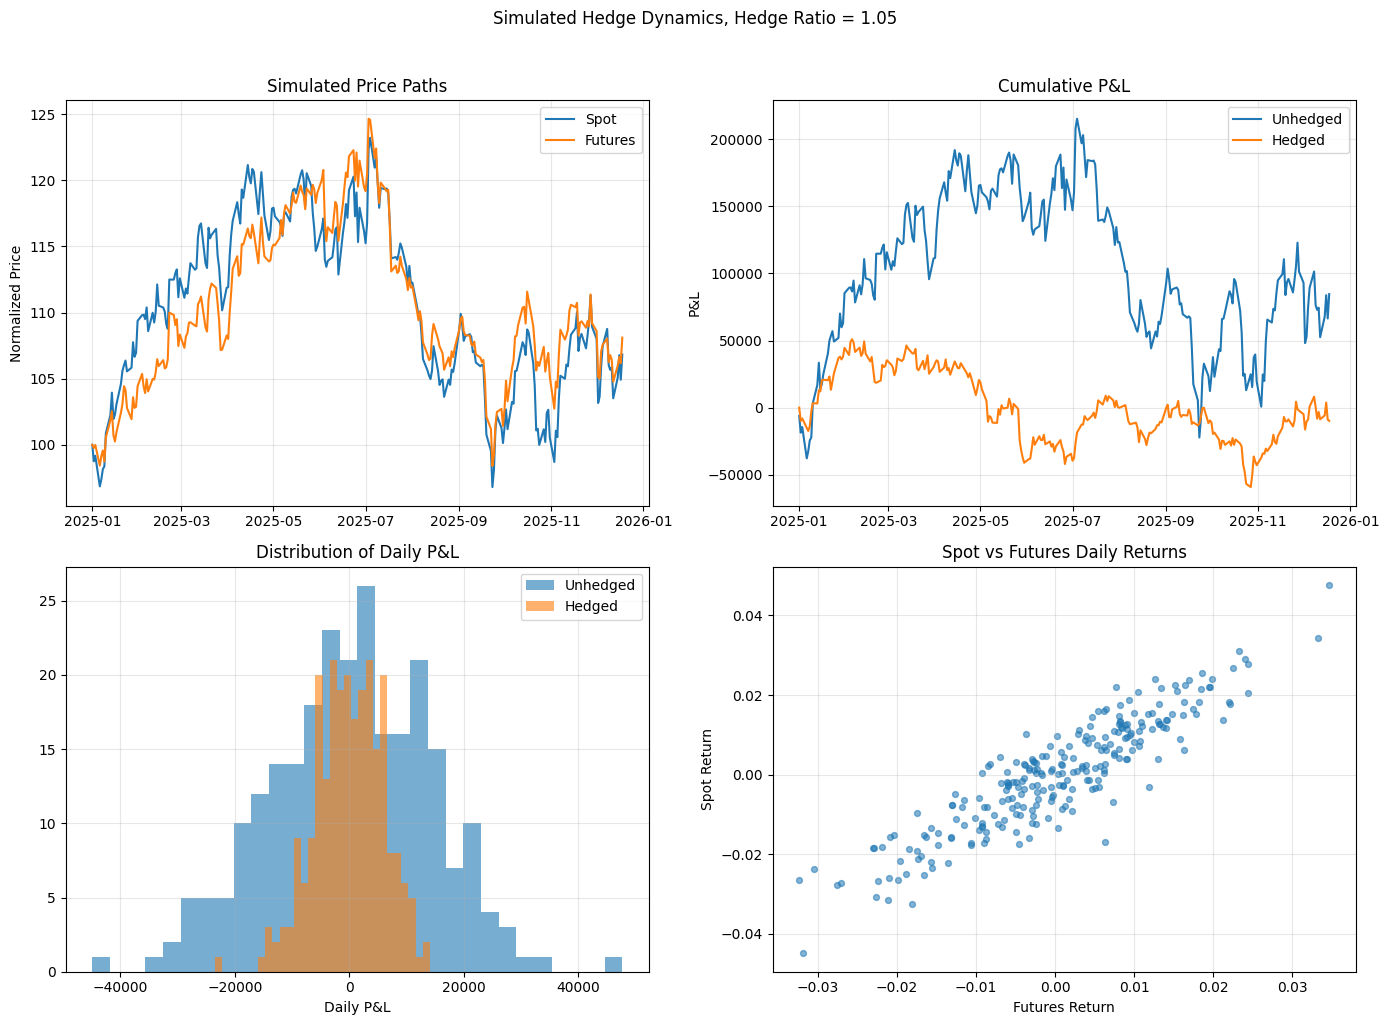

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


normalized_prices = sim_data[['spot_price', 'futures_price']].div(
    sim_data[['spot_price', 'futures_price']].iloc[0]
).mul(100)


axes[0, 0].plot(normalized_prices.index, normalized_prices['spot_price'], label='Spot')
axes[0, 0].plot(normalized_prices.index, normalized_prices['futures_price'], label='Futures')
axes[0, 0].set_title('Simulated Price Paths')
axes[0, 0].set_ylabel('Normalized Price')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)


axes[0, 1].plot(sim_data.index, sim_data['cum_unhedged_pnl'], label='Unhedged')
axes[0, 1].plot(sim_data.index, sim_data['cum_hedged_pnl'], label='Hedged')
axes[0, 1].set_title('Cumulative P&L')
axes[0, 1].set_ylabel('P&L')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)


axes[1, 0].hist(sim_data['unhedged_pnl'], bins=30, alpha=0.6, label='Unhedged')
axes[1, 0].hist(sim_data['hedged_pnl'], bins=30, alpha=0.6, label='Hedged')
axes[1, 0].set_title('Distribution of Daily P&L')
axes[1, 0].set_xlabel('Daily P&L')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)


axes[1, 1].scatter(
    sim_data['futures_return'],
    sim_data['spot_return'],
    alpha=0.55,
    s=18
)
axes[1, 1].set_title('Spot vs Futures Daily Returns')
axes[1, 1].set_xlabel('Futures Return')
axes[1, 1].set_ylabel('Spot Return')
axes[1, 1].grid(True, alpha=0.3)


plt.suptitle(f'Simulated Hedge Dynamics, Hedge Ratio = {hedge_ratio:.2f}', y=1.02)
plt.tight_layout()
plt.show()

## 9. Why Hedges Fail




Common reasons include:




- basis risk
- wrong hedge ratio
- timing mismatch between exposure and hedge maturity
- nonlinear payoffs not captured by a linear hedge
- liquidity and transaction costs
- model risk and parameter instability

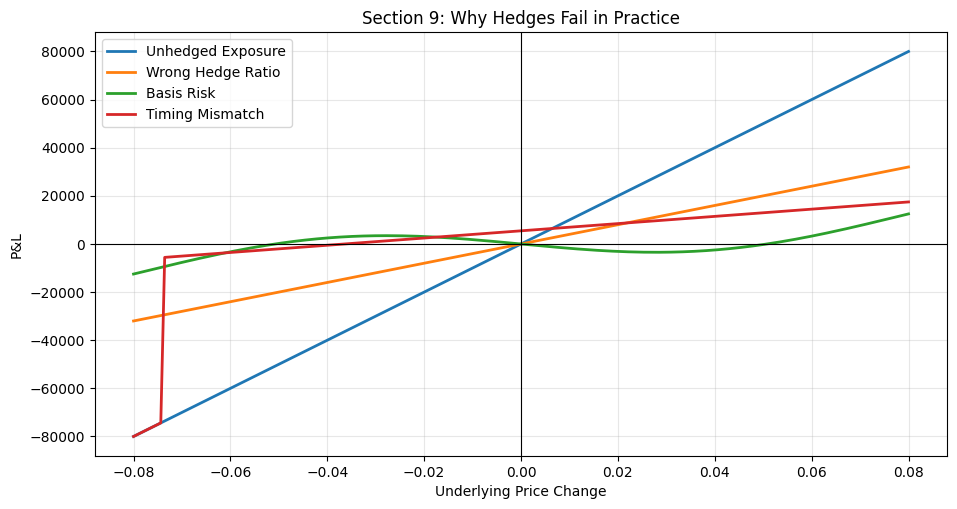

In [18]:
failure_levels = np.linspace(-0.08, 0.08, 200)
base_exposure = 1_000_000 * failure_levels
wrong_ratio = 1_000_000 * (failure_levels - 0.6 * failure_levels)
basis_risk_case = 1_000_000 * (failure_levels - 0.85 * (failure_levels + 0.01 * np.sin(40 * failure_levels)))
timing_mismatch = 1_000_000 * (failure_levels - 0.85 * np.roll(failure_levels, 8))
timing_mismatch[:8] = 1_000_000 * failure_levels[:8]


plt.figure(figsize=(11, 5.5))
plt.plot(failure_levels, base_exposure, label='Unhedged Exposure', linewidth=2)
plt.plot(failure_levels, wrong_ratio, label='Wrong Hedge Ratio', linewidth=2)
plt.plot(failure_levels, basis_risk_case, label='Basis Risk', linewidth=2)
plt.plot(failure_levels, timing_mismatch, label='Timing Mismatch', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Section 9: Why Hedges Fail in Practice')
plt.xlabel('Underlying Price Change')
plt.ylabel('P&L')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Summary




A hedge reduces unwanted risk by offsetting an existing exposure. The hedge ratio determines how much protection is applied, while a perfect hedge is a special case where risk is eliminated entirely. In most markets, the realistic objective is not perfection but a material reduction in variance or downside risk.

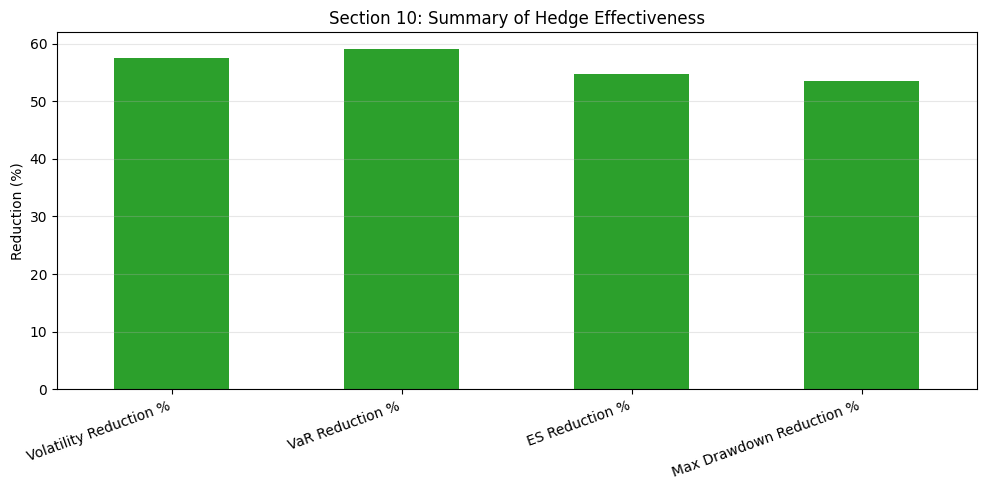

In [19]:
summary_metrics = pd.Series(
    {
        'Volatility Reduction %': 100 * (1 - sim_data['hedged_pnl'].std() / sim_data['unhedged_pnl'].std()),
        'VaR Reduction %': 100 * (1 - abs(sim_data['hedged_pnl'].quantile(0.05)) / abs(sim_data['unhedged_pnl'].quantile(0.05))),
        'ES Reduction %': 100 * (1 - abs(expected_shortfall(sim_data['hedged_pnl'])) / abs(expected_shortfall(sim_data['unhedged_pnl']))),
        'Max Drawdown Reduction %': 100 * (1 - abs(max_drawdown(sim_data['cum_hedged_pnl'])) / abs(max_drawdown(sim_data['cum_unhedged_pnl'])))
    }
)


ax = summary_metrics.plot(kind='bar', figsize=(10, 5), color='tab:green')
ax.set_title('Section 10: Summary of Hedge Effectiveness')
ax.set_ylabel('Reduction (%)')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 11. Exercises




1. Compute the minimum-variance hedge ratio for different values of correlation and interpret the result.
2. Build a small equity portfolio and estimate the number of index futures contracts needed to hedge its beta.
3. Compare a duration hedge and a DV01 hedge for a bond portfolio.
4. Explain why an FX forward hedge can be closer to perfect than an equity index hedge.

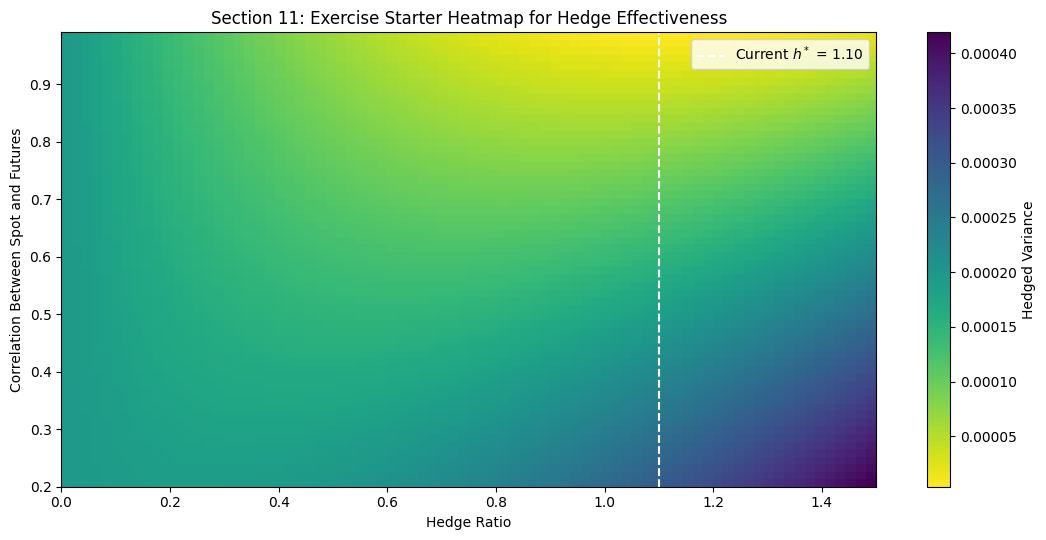

In [20]:
exercise_correlations = np.linspace(0.2, 0.99, 60)
exercise_ratios = np.linspace(0.0, 1.5, 80)
variance_grid = np.zeros((len(exercise_correlations), len(exercise_ratios)))


for i, corr in enumerate(exercise_correlations):
    for j, ratio in enumerate(exercise_ratios):
        variance_grid[i, j] = sigma_spot ** 2 + ratio ** 2 * sigma_futures ** 2 - 2 * ratio * corr * sigma_spot * sigma_futures


plt.figure(figsize=(11, 5.5))
image = plt.imshow(
    variance_grid,
    aspect='auto',
    origin='lower',
    extent=[exercise_ratios.min(), exercise_ratios.max(), exercise_correlations.min(), exercise_correlations.max()],
    cmap='viridis_r'
 )
plt.colorbar(image, label='Hedged Variance')
plt.axvline(h_star, color='white', linestyle='--', linewidth=1.5, label=f'Current $h^*$ = {h_star:.2f}')
plt.title('Section 11: Exercise Starter Heatmap for Hedge Effectiveness')
plt.xlabel('Hedge Ratio')
plt.ylabel('Correlation Between Spot and Futures')
plt.legend()
plt.tight_layout()
plt.show()